# MOBPY Example: Categorical Binning with 60+ Categories
### E-Commerce Fraud Detection — Merchant Category Risk Grouping

This notebook builds a **synthetic** e-commerce fraud dataset with **60 merchant categories**
and uses MOBPY's categorical binning path to group them into meaningful risk tiers.

| Property | This notebook |
|---|---|
| Dataset | Synthetic — fully reproducible with `np.random.default_rng(42)` |
| Rows | ~8 000 transactions |
| Feature x | `merchant_category` — **60 unique string values** |
| Target y | `is_fraud` — binary (0 = legitimate, 1 = fraudulent) |
| True underlying structure | 5 risk tiers hand-crafted into the DGP |
| Key showcase | `plot_categorical_merge` — 60 bars grouped and coloured by final bin |

---
## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from MOBPY import MonotonicBinner, BinningConstraints
from MOBPY.plot import (
    plot_woe_bars,
    plot_event_rate,
    plot_categorical_merge,
)

---
## 2. Synthetic Data Generation

We manually assign each merchant category a **true fraud rate** belonging to one of five risk tiers:

| Tier | Fraud rate range | # categories | Example merchants |
|---|---|---|---|
| 1 — Very High | 54 – 68 % | 6 | crypto exchange, gift cards, wire transfers |
| 2 — High | 34 – 49 % | 8 | luxury watches, online jewelry, gaming keys |
| 3 — Medium-High | 21 – 28 % | 10 | general electronics, airline tickets, art gallery |
| 4 — Medium | 11 – 18 % | 16 | clothing, shoes, home improvement, pet supplies |
| 5 — Low | 2 – 8 % | 20 | grocery, pharmacy, utility, government payment |

Transaction counts are proportional to real-world merchant popularity  
(everyday merchants like `grocery_store` get 3× more rows than niche ones).

In [2]:
# True fraud rates per merchant category (data-generating process)
MERCHANT_RATES = {
    # ── Tier 1: Very High Fraud  (54–68%) ──────────────────────────────────
    'crypto_exchange':     0.68,
    'gift_card_online':    0.62,
    'online_gambling':     0.59,
    'wire_transfer_svc':   0.65,
    'pawn_shop':           0.56,
    'prepaid_debit_card':  0.54,
    # ── Tier 2: High Fraud  (34–49%) ───────────────────────────────────────
    'luxury_watches':      0.47,
    'electronics_luxury':  0.44,
    'jewelry_online':      0.49,
    'designer_fashion':    0.39,
    'digital_game_keys':   0.36,
    'money_transfer_app':  0.42,
    'online_auction':      0.38,
    'vape_tobacco_online': 0.34,
    # ── Tier 3: Medium-High  (21–28%) ──────────────────────────────────────
    'electronics_general': 0.28,
    'sporting_goods':      0.23,
    'cosmetics_premium':   0.27,
    'travel_agency':       0.25,
    'airline_tickets':     0.22,
    'hotel_booking':       0.26,
    'car_rental':          0.21,
    'musical_instruments': 0.24,
    'art_gallery':         0.28,
    'furniture_luxury':    0.22,
    # ── Tier 4: Medium  (11–18%) ───────────────────────────────────────────
    'clothing_retail':     0.17,
    'shoes_retail':        0.15,
    'books_online':        0.11,
    'toys_and_games':      0.14,
    'home_improvement':    0.13,
    'office_supplies':     0.11,
    'pet_supplies':        0.12,
    'garden_supplies':     0.13,
    'kitchen_appliances':  0.16,
    'baby_products':       0.11,
    'health_supplements':  0.18,
    'outdoor_equipment':   0.14,
    'photography_gear':    0.16,
    'auto_parts':          0.15,
    'restaurant_fine':     0.12,
    'wine_and_spirits':    0.17,
    # ── Tier 5: Low  (2–8%) ────────────────────────────────────────────────
    'grocery_store':       0.05,
    'pharmacy':            0.04,
    'gas_station':         0.05,
    'fast_food':           0.04,
    'utility_payment':     0.03,
    'insurance_payment':   0.03,
    'medical_clinic':      0.04,
    'dental_office':       0.04,
    'gym_membership':      0.06,
    'streaming_service':   0.05,
    'software_saas':       0.07,
    'education_platform':  0.05,
    'charity_donation':    0.03,
    'parking_garage':      0.04,
    'public_transit':      0.03,
    'supermarket':         0.05,
    'hardware_store':      0.06,
    'post_office':         0.03,
    'bank_service_fee':    0.06,
    'government_payment':  0.02,
}

print(f"Total merchant categories: {len(MERCHANT_RATES)}")

Total merchant categories: 60


In [3]:
rng = np.random.default_rng(42)

# Everyday categories get ~3x more transactions
HIGH_VOLUME = {
    'grocery_store', 'supermarket', 'fast_food', 'gas_station',
    'pharmacy', 'streaming_service', 'utility_payment', 'restaurant_fine',
}
LOW_VOLUME = {
    'pawn_shop', 'art_gallery', 'post_office', 'government_payment',
    'charity_donation', 'dental_office', 'musical_instruments',
    'wire_transfer_svc', 'car_rental',
}

N_BASE = 100   # base transactions per category

records = []
for cat, rate in MERCHANT_RATES.items():
    if cat in HIGH_VOLUME:
        n = int(rng.integers(270, 350))
    elif cat in LOW_VOLUME:
        n = int(rng.integers(60, 90))
    else:
        n = int(rng.integers(90, 140))
    frauds = rng.binomial(n=1, p=rate, size=n)
    records.append(pd.DataFrame({'merchant_category': cat, 'is_fraud': frauds}))

df = (
    pd.concat(records, ignore_index=True)
    .sample(frac=1, random_state=42)
    .reset_index(drop=True)
)

print(f"Total rows        : {len(df):,}")
print(f"Unique categories : {df['merchant_category'].nunique()}")
print(f"Overall fraud rate: {df['is_fraud'].mean():.1%}")
print(f"Fraud cases       : {df['is_fraud'].sum():,}")
print()
print("Sample transactions:")
display(df.sample(8, random_state=1).reset_index(drop=True))

Total rows        : 8,195
Unique categories : 60
Overall fraud rate: 17.6%
Fraud cases       : 1,440

Sample transactions:


,merchant_category,is_fraud
0,garden_supplies,0
1,dental_office,0
2,electronics_luxury,1
3,electronics_general,1
4,restaurant_fine,0
5,fast_food,0
6,fast_food,0
7,gym_membership,0


---
## 3. Exploratory Data Analysis

Before binning, let's look at the **raw observed fraud rate per merchant category** sorted ascending.  
This is what `plot_categorical_merge` will later group and colour by bin.

Min fraud rate : 1.3%  (government_payment)
Max fraud rate : 69.1%  (crypto_exchange)
Mean fraud rate: 20.5%
Median n/cat   : 116



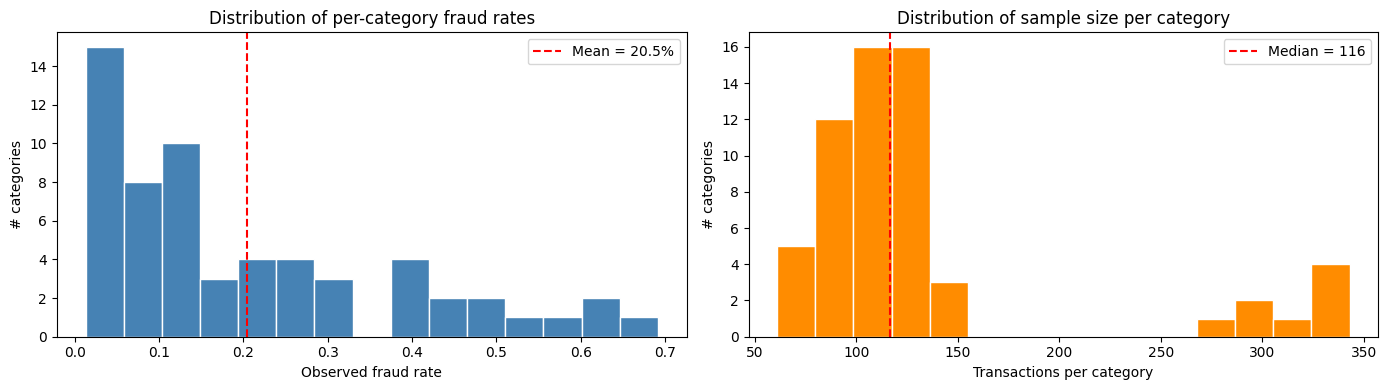

In [4]:
cat_stats = (
    df.groupby('merchant_category')['is_fraud']
    .agg(n='count', fraud='sum')
    .assign(fraud_rate=lambda d: d['fraud'] / d['n'])
    .sort_values('fraud_rate')
)

print(f"Min fraud rate : {cat_stats['fraud_rate'].min():.1%}  ({cat_stats.index[0]})")
print(f"Max fraud rate : {cat_stats['fraud_rate'].max():.1%}  ({cat_stats.index[-1]})")
print(f"Mean fraud rate: {cat_stats['fraud_rate'].mean():.1%}")
print(f"Median n/cat   : {cat_stats['n'].median():.0f}")
print()

# Distribution of observed rates
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(cat_stats['fraud_rate'], bins=15, color='steelblue', edgecolor='white')
axes[0].axvline(cat_stats['fraud_rate'].mean(), color='red', linestyle='--',
                label=f"Mean = {cat_stats['fraud_rate'].mean():.1%}")
axes[0].set_xlabel('Observed fraud rate')
axes[0].set_ylabel('# categories')
axes[0].set_title('Distribution of per-category fraud rates')
axes[0].legend()

axes[1].hist(cat_stats['n'], bins=15, color='darkorange', edgecolor='white')
axes[1].axvline(cat_stats['n'].median(), color='red', linestyle='--',
                label=f"Median = {cat_stats['n'].median():.0f}")
axes[1].set_xlabel('Transactions per category')
axes[1].set_ylabel('# categories')
axes[1].set_title('Distribution of sample size per category')
axes[1].legend()

plt.tight_layout()
plt.show()

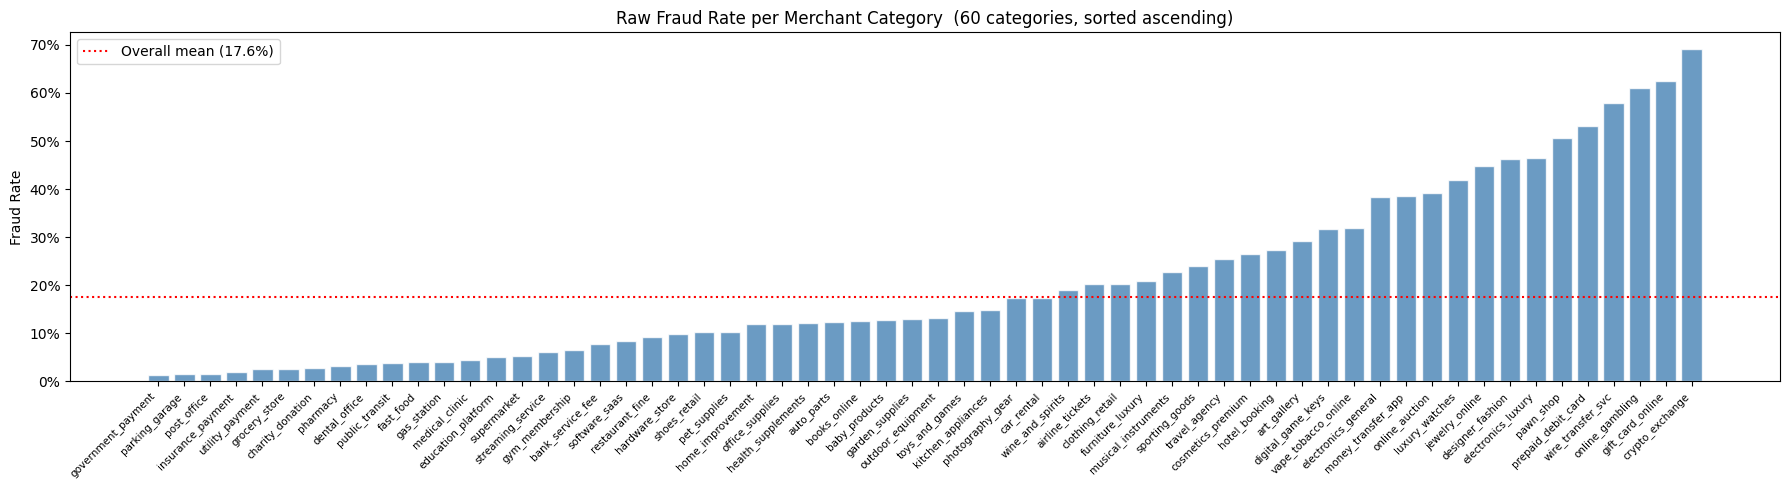

The 5 lowest-fraud categories:


,n,fraud_rate
merchant_category,,
government_payment,77,0.012987
parking_garage,122,0.016393
post_office,61,0.016393
insurance_payment,107,0.018692
utility_payment,298,0.026846


The 5 highest-fraud categories:


,n,fraud_rate
merchant_category,,
prepaid_debit_card,128,0.531250
wire_transfer_svc,88,0.579545
online_gambling,105,0.609524
gift_card_online,128,0.625000
crypto_exchange,94,0.691489


In [5]:
# Full sorted bar chart of raw fraud rates
overall_rate = df['is_fraud'].mean()

fig, ax = plt.subplots(figsize=(18, 5))
bars = ax.bar(
    range(len(cat_stats)),
    cat_stats['fraud_rate'],
    color='steelblue', alpha=0.8, edgecolor='white',
)
ax.axhline(overall_rate, color='red', linestyle=':', linewidth=1.5,
           label=f'Overall mean ({overall_rate:.1%})')
ax.set_xticks(range(len(cat_stats)))
ax.set_xticklabels(cat_stats.index, rotation=45, ha='right', fontsize=7.5)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.set_ylabel('Fraud Rate')
ax.set_title(
    f'Raw Fraud Rate per Merchant Category  '
    f'({len(cat_stats)} categories, sorted ascending)',
    fontsize=12,
)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print("The 5 lowest-fraud categories:")
display(cat_stats.head(5)[['n', 'fraud_rate']])
print("The 5 highest-fraud categories:")
display(cat_stats.tail(5)[['n', 'fraud_rate']])

---
## 4. Categorical Binning

MOBPY's categorical path (activated by `x_type='categorical'`) iteratively merges the pair of
adjacent-in-rate categories whose chi-square test produces the **largest p-value** (most similar)
until all remaining pairs are statistically distinguishable or `min_bins` is reached.

Key parameters here:
- `categorical_alpha=0.05` — merge if adjusted p-value ≥ 0.05 (categories not distinguishable)
- `max_label_cats=4` — truncate bin labels: `{cat_a, cat_b, cat_c, cat_d, ...+N}`
- `min_bins=2`, `max_bins=60` — allow the algorithm full freedom

In [6]:
binner = MonotonicBinner(
    df=df,
    x='merchant_category',
    y='is_fraud',
    x_type='categorical',
    categorical_alpha=0.05,
    categorical_correction='holm',
    constraints=BinningConstraints(
        max_bins=60,
        min_bins=2,
        min_samples=50,
    ),
    max_label_cats=3,
)
binner.fit()

diag = binner.get_diagnostics()
print(f"Initial categories : {diag['n_initial_categories']}")
print(f"Final bins         : {diag['n_final_bins']}")
print(f"Constraints met    : {diag['constraints_satisfied']}")

Initial categories : 60
Final bins         : 7
Constraints met    : {'max_bins': True, 'min_bins': True, 'min_samples': True, 'min_positives': True, 'min_negatives': True}


In [7]:
bins_df = binner.bins_()

print("Merged bins — categories and pooled statistics:")
print()
for i, row in bins_df.iterrows():
    members = sorted(row['categories'])
    print(f"Bin {i+1}  │  n={row['n']:4d}  │  fraud_rate={row['mean']:.1%}  │  {len(members)} categories")
    print(f"         │  {', '.join(members)}")
    print()

Merged bins — categories and pooled statistics:

Bin 1  │  n= 504  │  fraud_rate=43.5%  │  4 categories
         │  designer_fashion, electronics_luxury, luxury_watches, money_transfer_app

Bin 2  │  n= 730  │  fraud_rate=56.3%  │  7 categories
         │  crypto_exchange, gift_card_online, online_auction, online_gambling, pawn_shop, prepaid_debit_card, wire_transfer_svc

Bin 3  │  n=1488  │  fraud_rate=6.2%  │  8 categories
         │  baby_products, charity_donation, education_platform, gas_station, government_payment, medical_clinic, restaurant_fine, streaming_service

Bin 4  │  n=1247  │  fraud_rate=12.0%  │  12 categories
         │  auto_parts, bank_service_fee, books_online, car_rental, furniture_luxury, garden_supplies, hardware_store, health_supplements, office_supplies, outdoor_equipment, post_office, shoes_retail

Bin 5  │  n=2301  │  fraud_rate=4.0%  │  12 categories
         │  dental_office, fast_food, grocery_store, gym_membership, insurance_payment, parking_garage, pet_

In [8]:
summary = binner.summary_()
total_iv = summary['iv'].sum()

print(f"Total IV = {total_iv:.4f}")
print()
display(
    summary[['bucket', 'count', 'count_pct', 'mean', 'woe', 'iv']]
    .rename(columns={'count': 'n', 'count_pct': 'n_%', 'mean': 'fraud_rate'})
    .style.format({'n_%': '{:.1f}', 'fraud_rate': '{:.1%}', 'woe': '{:.4f}', 'iv': '{:.4f}'})
)

Total IV = 1.2693



,bucket,n,n_%,fraud_rate,woe,iv
0,"{designer_fashion, electronics_luxury, luxury_watches, ...+1}",504,6.2,43.5%,-1.2808,0.1407
1,"{crypto_exchange, gift_card_online, online_auction, ...+4}",730,8.9,56.3%,-1.7968,0.4273
2,"{baby_products, charity_donation, education_platform, ...+5}",1488,18.2,6.2%,1.1708,0.1669
3,"{auto_parts, bank_service_fee, books_online, ...+9}",1247,15.2,12.0%,0.4431,0.0258
4,"{dental_office, fast_food, grocery_store, ...+9}",2301,28.1,4.0%,1.6184,0.4240
5,"{cosmetics_premium, digital_game_keys, electronics_general, ...+5}",895,10.9,31.8%,-0.7837,0.0842
6,"{airline_tickets, art_gallery, clothing_retail, ...+6}",1030,12.6,18.4%,-0.0594,0.0005


---
## 5. WoE and Event-Rate Charts

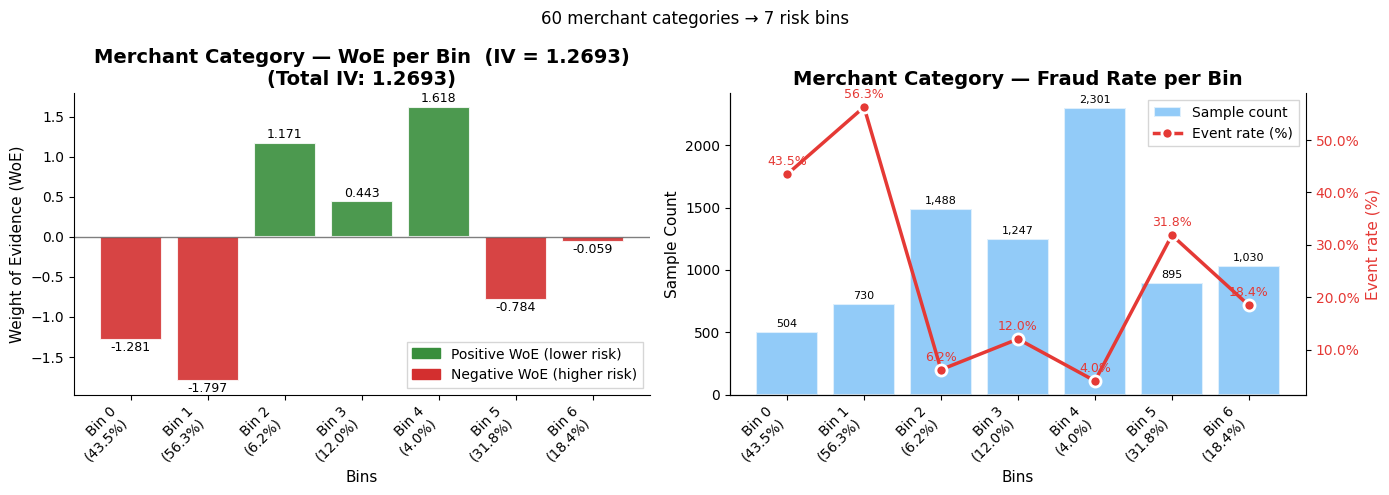

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_woe_bars(
    summary, ax=axes[0],
    title=f'Merchant Category — WoE per Bin  (IV = {total_iv:.4f})',
    show_iv=True, show_values=True,
    tick_labels='auto' # overwrite the max_label_cats settings when instantiate MonotonicBinner
)
plot_event_rate(
    summary, ax=axes[1],
    title='Merchant Category — Fraud Rate per Bin',
    show_counts=True, y_format='percentage',
    tick_labels='auto'
)

plt.suptitle(
    f'60 merchant categories → {diag["n_final_bins"]} risk bins',
    fontsize=12,
)
plt.tight_layout()
plt.show()

In [22]:
binner.bins_()

,categories,n,sum,mean,std,min,max
0,"[designer_fashion, electronics_luxury, luxury_...",504,219.0,0.434524,0.496187,0.0,1.0
1,"[crypto_exchange, gift_card_online, online_auc...",730,411.0,0.563014,0.496353,0.0,1.0
2,"[baby_products, charity_donation, education_pl...",1488,92.0,0.061828,0.240924,0.0,1.0
3,"[auto_parts, bank_service_fee, books_online, c...",1247,150.0,0.120289,0.325429,0.0,1.0
4,"[dental_office, fast_food, grocery_store, gym_...",2301,93.0,0.040417,0.196978,0.0,1.0
5,"[cosmetics_premium, digital_game_keys, electro...",895,285.0,0.318436,0.466130,0.0,1.0
6,"[airline_tickets, art_gallery, clothing_retail...",1030,190.0,0.184466,0.388052,0.0,1.0


---
## 6. `plot_categorical_merge` — The Merge Process

This is the key visualisation.  Every one of the **60 original categories** is shown as a bar;
bars are **grouped by final bin** (same colour = merged together), with a gap between groups.
Within each group bars are sorted by ascending fraud rate so within-bin spread is visible.

- **Dashed horizontal line** — pooled fraud rate for that bin  
- **Dotted black line** — overall dataset mean  
- **Group header** — bin number, pooled rate, category count

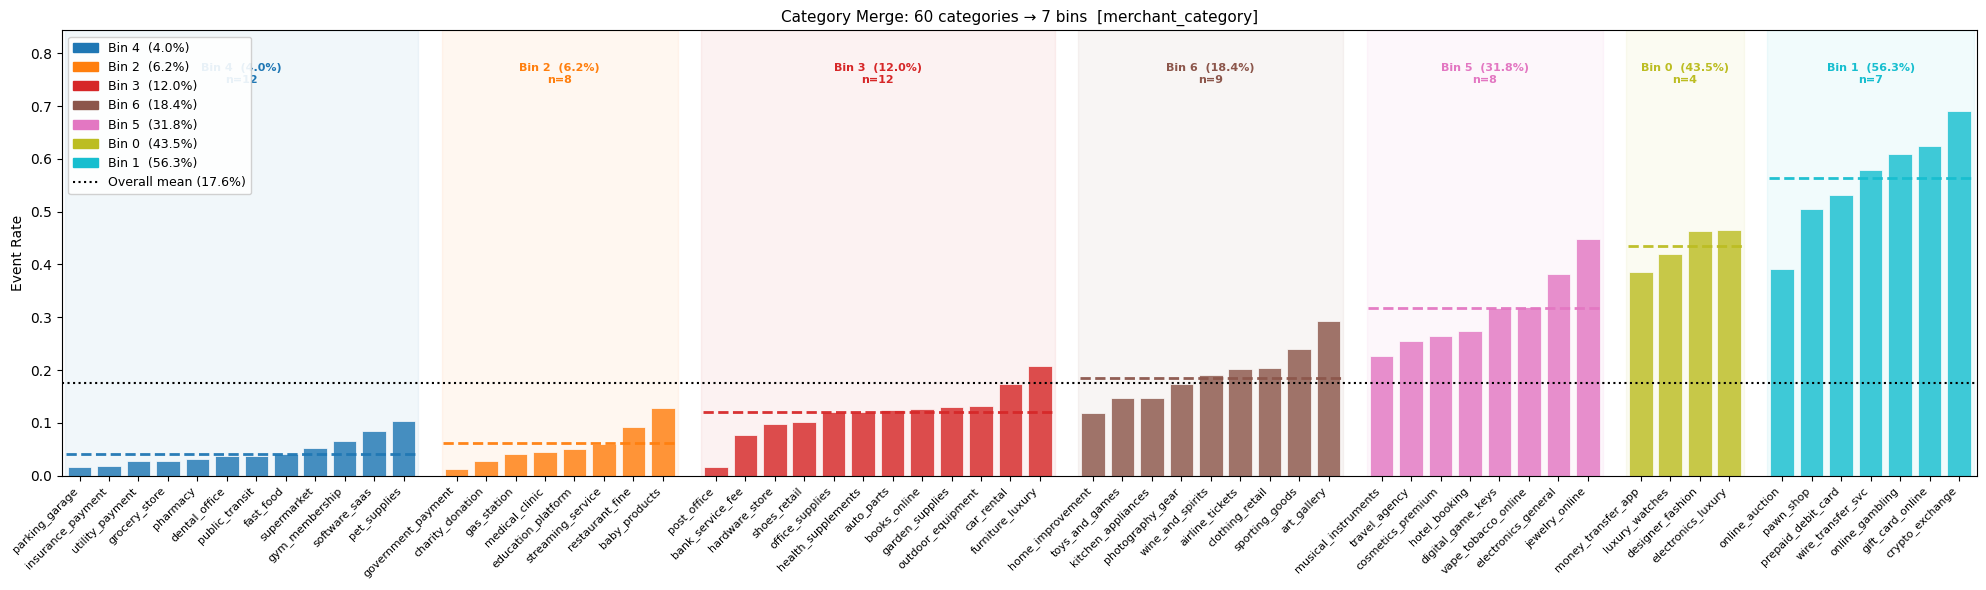

In [11]:
fig, ax = plt.subplots(figsize=(20, 6))
plot_categorical_merge(
    binner,
    ax=ax,
    show_counts=False,   # 60 bars — skip per-bar counts to avoid clutter
)
plt.tight_layout()
plt.show()

---
## 7. Effect of `categorical_alpha`

Lower alpha → harder to merge (keep more bins).  
Higher alpha → easier to merge (fewer bins).  

The three panels below show the merge result at three alpha levels side-by-side,
making it easy to see which category boundaries are statistically robust.

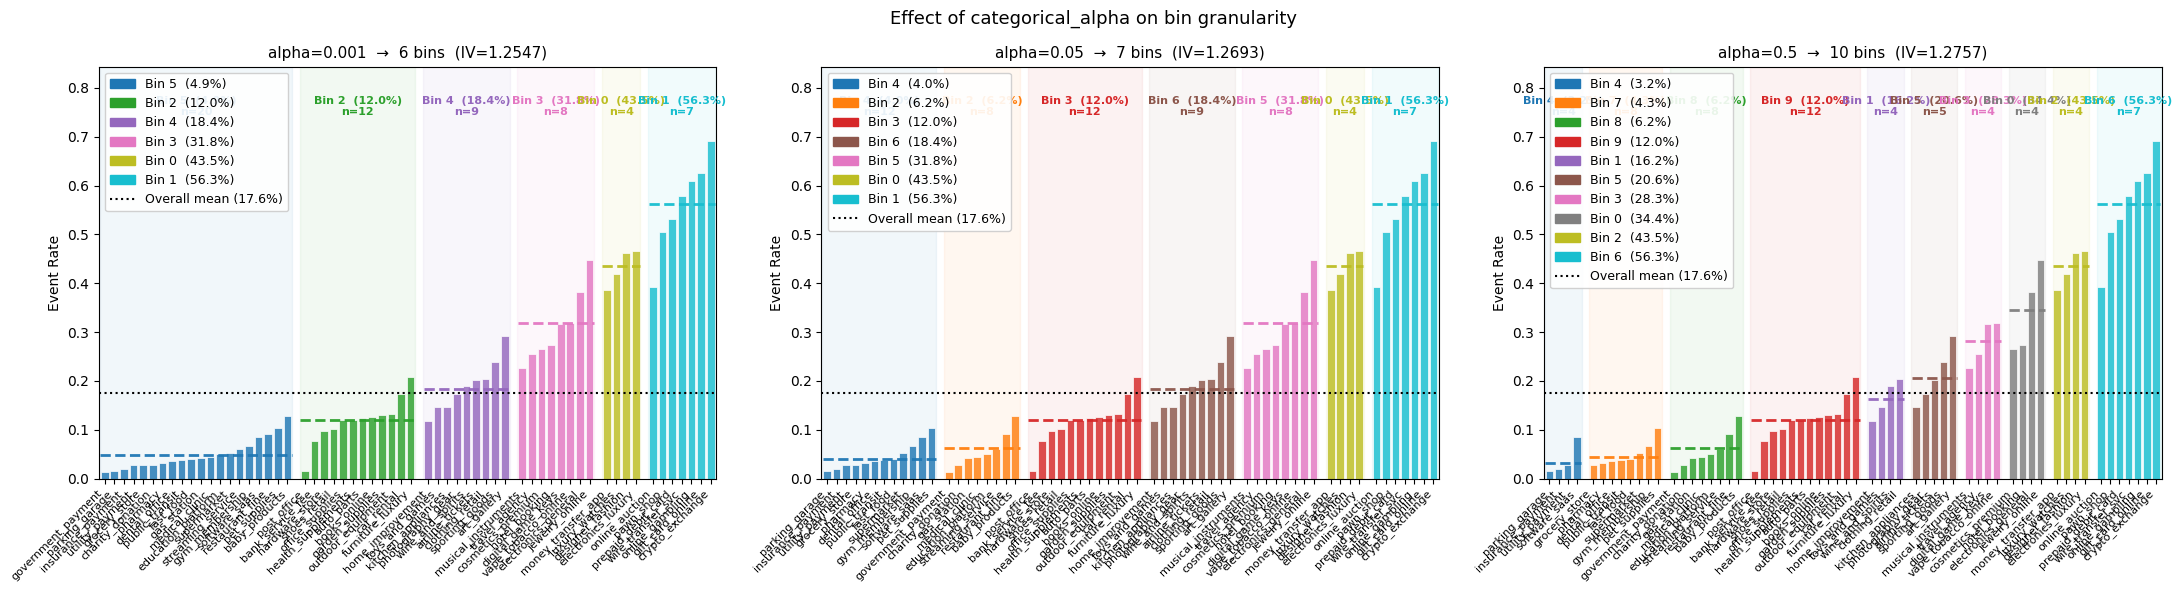

In [12]:
alphas = [0.001, 0.05, 0.50]
loose  = BinningConstraints(max_bins=60, min_bins=2, min_samples=50)

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

for ax, alpha in zip(axes, alphas):
    b = MonotonicBinner(
        df=df, x='merchant_category', y='is_fraud',
        x_type='categorical',
        categorical_alpha=alpha,
        constraints=loose,
        max_label_cats=3,
    )
    b.fit()
    n_final = b.get_diagnostics()['n_final_bins']
    iv = b.summary_()['iv'].sum()
    plot_categorical_merge(
        b, ax=ax,
        title=f'alpha={alpha}  →  {n_final} bins  (IV={iv:.4f})',
        show_counts=False,
    )

plt.suptitle('Effect of categorical_alpha on bin granularity', fontsize=13)
plt.tight_layout()
plt.show()

---
## 8. `transform()` — Applying Bin Labels

`transform()` maps each raw category string to its bin label or WoE score.
Unseen categories (merchants not seen during training) are handled by `unseen_categories='unknown'`.

In [13]:
# Simulate train/test split on transactions
train = df.sample(frac=0.8, random_state=42)
test  = df.drop(train.index)

train_binner = MonotonicBinner(
    df=train,
    x='merchant_category',
    y='is_fraud',
    x_type='categorical',
    categorical_alpha=0.05,
    constraints=BinningConstraints(max_bins=60, min_bins=2, min_samples=30),
    unseen_categories='unknown',
    max_label_cats=3,
)
train_binner.fit()

n_train_bins = train_binner.get_diagnostics()['n_final_bins']
print(f"Trained on {len(train):,} transactions → {n_train_bins} bins")
print()

# Apply to test set
test_out = test[['merchant_category', 'is_fraud']].copy()
test_out['bin_label'] = train_binner.transform(test['merchant_category'], assign='interval').values
test_out['woe_score'] = train_binner.transform(test['merchant_category'], assign='woe').values

# Summary of test set by bin
print("Test-set fraud rate per bin (out-of-sample validation):")
display(
    test_out.groupby('bin_label')[['is_fraud', 'woe_score']]
    .agg(n=('is_fraud', 'count'), fraud_rate=('is_fraud', 'mean'), woe=('woe_score', 'first'))
    .sort_values('fraud_rate')
    .style.format({'fraud_rate': '{:.1%}', 'woe': '{:.4f}'})
)

Trained on 6,556 transactions → 6 bins

Test-set fraud rate per bin (out-of-sample validation):


,n,fraud_rate,woe
bin_label,,,
"{education_platform, fast_food, gas_station, ...+13}",708,4.8%,1.4196
"{auto_parts, bank_service_fee, charity_donation, ...+9}",268,10.1%,0.7445
"{baby_products, books_online, car_rental, ...+11}",286,18.9%,-0.0520
"{designer_fashion, digital_game_keys, electronics_luxury, ...+5}",171,32.7%,-1.1404
"{airline_tickets, art_gallery, electronics_general, ...+1}",92,44.6%,-0.6626
"{crypto_exchange, gift_card_online, online_gambling, ...+3}",114,56.1%,-1.9244


In [14]:
# Unseen merchant categories
new_merchants = pd.Series([
    'grocery_store',       # known — low risk
    'crypto_exchange',     # known — very high risk
    'nft_marketplace',     # unseen
    None,                  # missing value
    'dark_web_store',      # unseen
])

print("Input:   ", new_merchants.tolist())
print("Interval:", train_binner.transform(new_merchants, assign='interval').tolist())
print("WoE:     ", [f"{v:.4f}" if pd.notna(v) else str(v)
                    for v in train_binner.transform(new_merchants, assign='woe')])
print()
print("None          → 'Missing'  (WoE = 0.0)")
print("Unseen string → 'Unknown'  (WoE = NaN)  — unseen_categories='unknown'")

Input:    ['grocery_store', 'crypto_exchange', 'nft_marketplace', None, 'dark_web_store']
Interval: ['{education_platform, fast_food, gas_station, ...+13}', '{crypto_exchange, gift_card_online, online_gambling, ...+3}', 'Unknown', 'Missing', 'Unknown']
WoE:      ['1.4196', '-1.9244', 'nan', '0.0000', 'nan']

None          → 'Missing'  (WoE = 0.0)
Unseen string → 'Unknown'  (WoE = NaN)  — unseen_categories='unknown'


---
## 9. Side-by-Side: Raw Rates vs Merge Result

The bottom panel is `plot_categorical_merge` — the categories are the same as the top bar chart
but now **coloured and grouped by bin**, making the merge decision transparent.

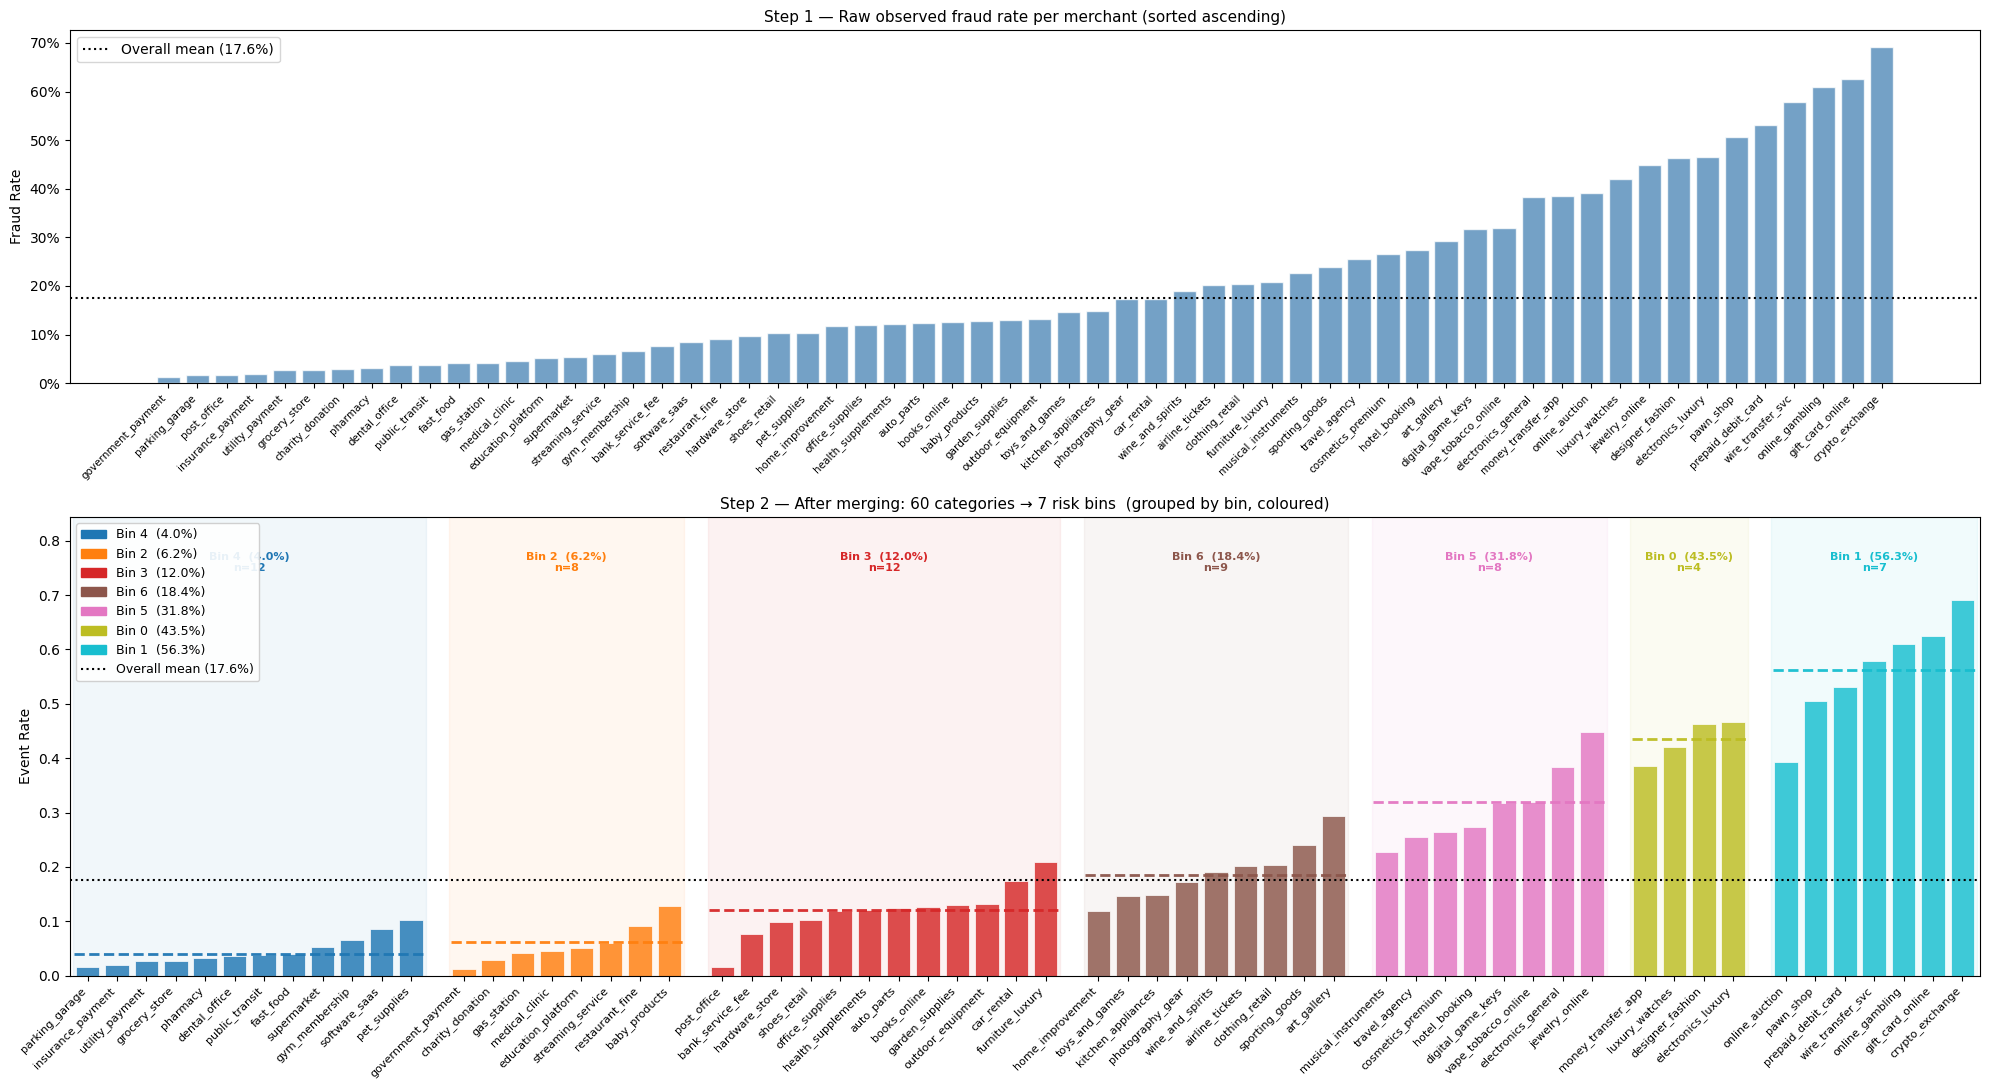

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(20, 11),
                         gridspec_kw={'height_ratios': [1, 1.3]})

# ── Top: raw unsorted (all grey) ──────────────────────────────────────────
axes[0].bar(
    range(len(cat_stats)),
    cat_stats['fraud_rate'],
    color='steelblue', alpha=0.75, edgecolor='white',
)
axes[0].axhline(
    df['is_fraud'].mean(), color='black', linestyle=':',
    linewidth=1.5, label=f'Overall mean ({df["is_fraud"].mean():.1%})',
)
axes[0].set_xticks(range(len(cat_stats)))
axes[0].set_xticklabels(cat_stats.index, rotation=45, ha='right', fontsize=7.5)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
axes[0].set_ylabel('Fraud Rate')
axes[0].set_title('Step 1 — Raw observed fraud rate per merchant (sorted ascending)', fontsize=11)
axes[0].legend()

# ── Bottom: merge process coloured by bin ────────────────────────────────
plot_categorical_merge(
    binner, ax=axes[1],
    title=f'Step 2 — After merging: 60 categories → {diag["n_final_bins"]} risk bins  '
          f'(grouped by bin, coloured)',
    show_counts=False,
)

plt.tight_layout()
plt.show()

---
## 10. Key Takeaways

| Topic | Detail |
|---|---|
| Activation | `x_type='categorical'` — default is `'numeric'` |
| Algorithm | Chi-square contingency test; iteratively merges the least-different pair |
| Scale | Works cleanly with 60+ categories; only O(k²) pairwise tests per iteration |
| `categorical_alpha` | Controls merge aggressiveness — lower = more bins; higher = fewer bins |
| `max_label_cats` | Truncates long set labels `{A, B, C, ...+N}` — keeps axes readable |
| `plot_categorical_merge` | Shows all categories as bars grouped by bin — the categorical analog of the PAVA process plot |
| `transform()` | Returns bin label or WoE; unseen categories → `'Unknown'` / `NaN` |